# Task 1: Data Exploration and Enrichment

## Understanding the Unified Schema

This notebook explores the Ethiopia Financial Inclusion dataset to understand its structure, content, and quality before enrichment.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully!")
print("Google Drive mounted!")

Mounted at /content/drive
Libraries imported successfully!
Google Drive mounted!


In [ ]:
from google.colab import files

print("=" * 80)
print("UPLOAD YOUR DATA FILES")
print("=" * 80)
print("\nPlease upload the following files:")
print("1. ethiopia_fi_unified_data.csv")
print("2. reference_codes.csv")
print("\nClick the 'Choose Files' button below and select your files.")

uploaded = files.upload()
uploaded = files.upload()

#list uploaded files
print("\nUploaded files:")
for filename in uploaded.keys():
    print(f"  - {filename}")

UPLOAD YOUR DATA FILES

Please upload the following files:
1. ethiopia_fi_unified_data.csv
2. reference_codes.csv

Click the 'Choose Files' button below and select your files.


Saving ethiopia_fi_unified_data.xlsx to ethiopia_fi_unified_data (1).xlsx


Saving reference_codes.xlsx to reference_codes.xlsx

Uploaded files:
  - reference_codes.xlsx


In [ ]:
uploaded_files = list(uploaded.keys())

#find the main dataset and reference file
raw_data_path = None
reference_codes_path = None

for filename in uploaded_files:
    if 'ethiopia_fi_unified_data' in filename and filename.endswith('.xlsx'):
        raw_data_path = filename
    elif 'reference_codes' in filename and filename.endswith('.xlsx'):
        reference_codes_path = filename

#if files weren't found in upload, check current directory
if raw_data_path is None:
    #list all files in current directory
    print("Files in current directory:", os.listdir())
    #try to find the files
    for file in os.listdir():
        if 'ethiopia_fi_unified_data' in file and file.endswith('.xlsx'):
            raw_data_path = file
        elif 'reference_codes' in file and file.endswith('.xlsx'):
            reference_codes_path = file

print(f"Main dataset: {raw_data_path}")
print(f"Reference codes: {reference_codes_path}")

#read the data - USING pd.read_excel() for Excel files
df = pd.read_excel(raw_data_path)
reference_df = pd.read_excel(reference_codes_path)

print("\n" + "=" * 80)
print("DATA LOADED SUCCESSFULLY")
print("=" * 80)
print(f"Main dataset shape: {df.shape}")
print(f"Reference codes shape: {reference_df.shape}")
print(f"\nMain dataset columns: {df.columns.tolist()}")
print(f"\nReference columns: {reference_df.columns.tolist()}")

Files in current directory: ['.config', 'ethiopia_fi_unified_data.xlsx', 'reference_codes.xlsx', 'ethiopia_fi_unified_data (1).xlsx', 'drive', 'sample_data']
Main dataset: ethiopia_fi_unified_data (1).xlsx
Reference codes: reference_codes.xlsx

DATA LOADED SUCCESSFULLY
Main dataset shape: (43, 34)
Reference codes shape: (71, 4)

Main dataset columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Reference columns: ['field', 'code', 'description', 'applies_to']


In [ ]:
#first few rows of the main dataset
print("=" * 80)
print("FIRST 10 ROWS OF MAIN DATASET")
print("=" * 80)
df.head(10)

FIRST 10 ROWS OF MAIN DATASET


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.00,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.00,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.00,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.00,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.00,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.00,NaN,percentage,%,2024-11-29,2024-10-15,2024-11-29,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN
6,REC_0007,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,4.70,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
7,REC_0008,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,9.45,NaN,percentage,%,2024-11-29,NaT,NaT,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Doubled from 2021,NaN
8,REC_0009,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,37.50,NaN,percentage,%,2023-06-30,NaT,NaT,FY2022/23,all,national,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Before major expansion,NaN
9,REC_0010,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,70.80,NaN,percentage,%,2025-06-30,NaT,NaT,FY2024/25,all,national,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,4G coverage doubled from 37.5% to 70.8%,Major infrastructure investment,NaN


In [ ]:
#check data types
print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)
print("\n")

#check for missing values
print("=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing_values = df.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percent': (missing_values.values / len(df)) * 100
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

DATA TYPES
record_id                      object
record_type                    object
category                       object
pillar                         object
indicator                      object
indicator_code                 object
indicator_direction            object
value_numeric                 float64
value_text                     object
value_type                     object
unit                           object
observation_date       datetime64[ns]
period_start           datetime64[ns]
period_end             datetime64[ns]
fiscal_year                    object
gender                         object
location                       object
region                        float64
source_name                    object
source_type                    object
source_url                     object
confidence                     object
related_indicator             float64
relationship_type             float64
impact_direction              float64
impact_magnitude              float64
i

RECORD TYPE DISTRIBUTION
record_type
observation    30
event          10
target          3
Name: count, dtype: int64




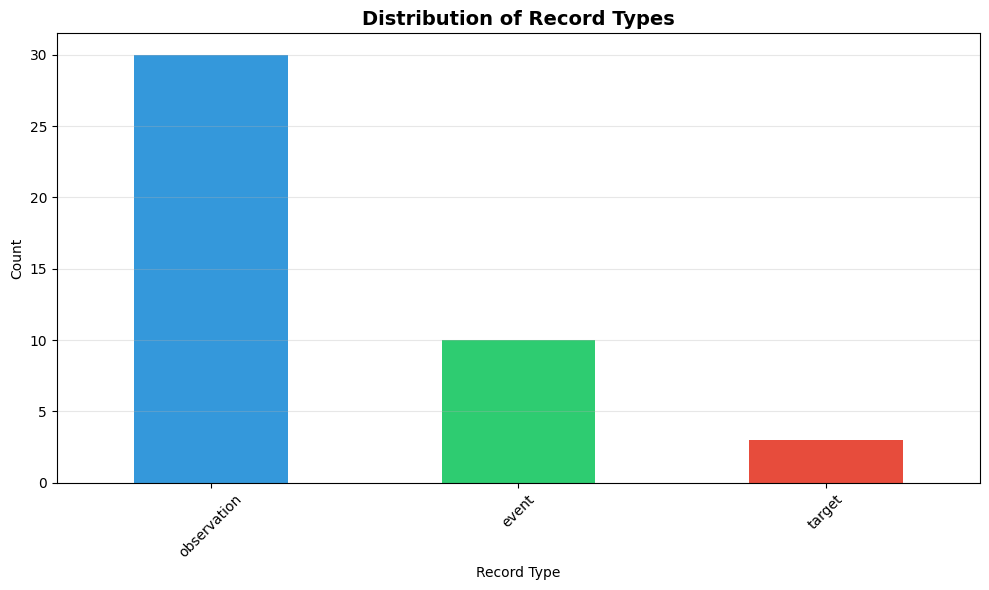

In [ ]:
#count by record_type
print("=" * 80)
print("RECORD TYPE DISTRIBUTION")
print("=" * 80)
record_type_counts = df['record_type'].value_counts()
print(record_type_counts)
print("\n")

#visualize record type distribution
plt.figure(figsize=(10, 6))
record_type_counts.plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Distribution of Record Types', fontsize=14, fontweight='bold')
plt.xlabel('Record Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#observations
observations = df[df['record_type'] == 'observation']

print("=" * 80)
print("OBSERVATIONS DETAILS")
print("=" * 80)
print(f"Number of observations: {len(observations)}")
print(f"Temporal range: {observations['observation_date'].min()} to {observations['observation_date'].max()}")
print(f"\nPillars covered: {observations['pillar'].unique().tolist()}")
print(f"\nIndicators: {observations['indicator_code'].nunique()} unique indicators")

#show observations by pillar
print("\nObservations by pillar:")
print(observations['pillar'].value_counts())

#show available columns for observations
print("\nAvailable columns in observations:")
print(observations.columns.tolist())

#show sample observations - dynamically select available columns
sample_cols = []
for col in ['indicator_code', 'indicator_name', 'value_numeric', 'observation_date', 'source_name']:
    if col in observations.columns:
        sample_cols.append(col)
    else:
        #try alternative column names
        if col == 'indicator_name' and 'indicator' in observations.columns:
            sample_cols.append('indicator')
        elif col == 'source_name' and 'source' in observations.columns:
            sample_cols.append('source')
        else:
            print(f"Note: '{col}' not found in columns")

print(f"\nSample observations (first 10) using available columns:")
if sample_cols:
    print(observations[sample_cols].head(10))
else:
    #if no specific columns found, show all columns
    print(observations.head(10))

OBSERVATIONS DETAILS
Number of observations: 30
Temporal range: 2014-12-31 00:00:00 to 2025-12-31 00:00:00

Pillars covered: ['ACCESS', 'USAGE', 'AFFORDABILITY', 'GENDER']

Indicators: 19 unique indicators

Observations by pillar:
pillar
ACCESS           14
USAGE            11
GENDER            4
AFFORDABILITY     1
Name: count, dtype: int64

Available columns in observations:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Sample observations (first 10) using available columns:
   indicator_code                 

In [ ]:
events = df[df['record_type'] == 'event']

print("=" * 80)
print("EVENTS DETAILS")
print("=" * 80)
print(f"Number of events: {len(events)}")
print(f"\nEvent categories:")
print(events['category'].value_counts())
print(f"\nDate range: {events['observation_date'].min()} to {events['observation_date'].max()}")

available_cols = []
for col in ['name', 'category', 'observation_date', 'description']:
    if col in events.columns:
        available_cols.append(col)

print("\nEvents summary:")
if available_cols:
    print(events[available_cols].head(10))
else:
    print(events.head(10))

EVENTS DETAILS
Number of events: 10

Event categories:
category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

Date range: 2021-05-17 00:00:00 to 2025-12-18 00:00:00

Events summary:
          category observation_date
33  product_launch       2021-05-17
34    market_entry       2022-08-01
35  product_launch       2023-08-01
36  infrastructure       2024-01-01
37          policy       2024-07-29
38       milestone       2024-10-01
39     partnership       2025-10-27
40  infrastructure       2025-12-18
41          policy       2021-09-01
42         pricing       2025-12-15


In [ ]:
impact_links = df[df['record_type'] == 'impact_link']

print("=" * 80)
print("IMPACT LINKS DETAILS")
print("=" * 80)
print(f"Number of impact links: {len(impact_links)}")
print(f"\nImpact directions:")
print(impact_links['impact_direction'].value_counts())
print(f"\nPillars affected: {impact_links['pillar'].unique().tolist()}")

available_cols = []
for col in ['parent_id', 'pillar', 'related_indicator', 'impact_direction', 'impact_magnitude', 'lag_months', 'evidence_basis']:
    if col in impact_links.columns:
        available_cols.append(col)

print("\nSample impact links:")
if available_cols:
    print(impact_links[available_cols].head(10))
else:
    print(impact_links.head(10))

IMPACT LINKS DETAILS
Number of impact links: 0

Impact directions:
Series([], Name: count, dtype: int64)

Pillars affected: []

Sample impact links:
Empty DataFrame
Columns: [pillar, related_indicator, impact_direction, impact_magnitude, lag_months, evidence_basis]
Index: []


In [ ]:
targets = df[df['record_type'] == 'target']

print("=" * 80)
print("TARGETS DETAILS")
print("=" * 80)
print(f"Number of targets: {len(targets)}")

available_cols = []
for col in ['name', 'pillar', 'indicator_code', 'value_numeric', 'observation_date', 'description']:
    if col in targets.columns:
        available_cols.append(col)

print("\nTarget details:")
if available_cols:
    print(targets[available_cols])
else:
    print(targets)

TARGETS DETAILS
Number of targets: 3

Target details:
    pillar indicator_code  value_numeric observation_date
30  ACCESS  ACC_OWNERSHIP          70.00       2025-12-31
31  ACCESS      ACC_FAYDA    90000000.00       2028-12-31
32  GENDER   GEN_MM_SHARE          50.00       2030-12-31


CONFIDENCE LEVEL DISTRIBUTION
confidence
high      40
medium     3
Name: count, dtype: int64

Confidence by record_type:

observation:
confidence
high      28
medium     2
Name: count, dtype: int64

target:
confidence
high      2
medium    1
Name: count, dtype: int64

event:
confidence
high    10
Name: count, dtype: int64


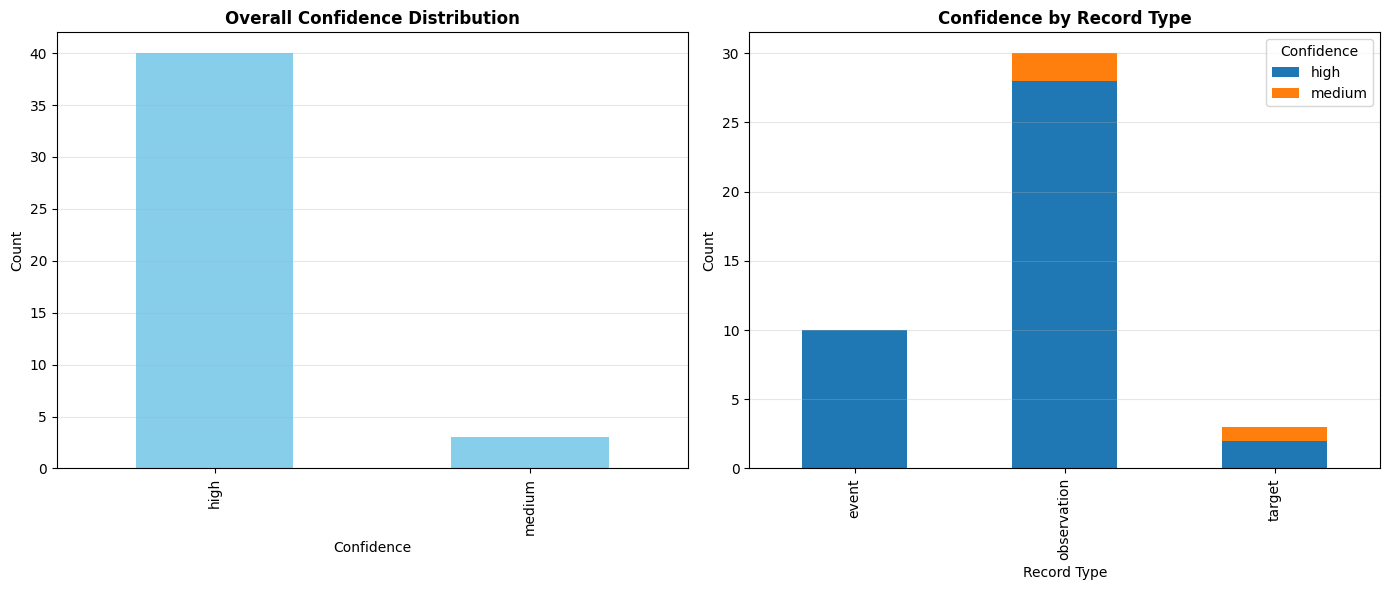

In [ ]:
print("=" * 80)
print("CONFIDENCE LEVEL DISTRIBUTION")
print("=" * 80)
confidence_dist = df['confidence'].value_counts()
print(confidence_dist)

print("\nConfidence by record_type:")
for record_type in df['record_type'].unique():
    subset = df[df['record_type'] == record_type]
    print(f"\n{record_type}:")
    print(subset['confidence'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

confidence_dist.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Overall Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

confidence_by_type = pd.crosstab(df['record_type'], df['confidence'])
confidence_by_type.plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Confidence by Record Type', fontweight='bold')
axes[1].set_xlabel('Record Type')
axes[1].set_ylabel('Count')
axes[1].legend(title='Confidence')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 80)
print("INDICATOR COVERAGE ANALYSIS")
print("=" * 80)

indicator_summary = observations.groupby(['indicator_code', 'pillar']).agg({
    'observation_date': ['min', 'max', 'count'],
    'value_numeric': ['mean', 'min', 'max']
}).round(2)

indicator_summary.columns = ['first_obs', 'last_obs', 'n_obs', 'mean_value', 'min_value', 'max_value']
indicator_summary = indicator_summary.sort_values('n_obs', ascending=False)
print(indicator_summary)

os.makedirs('reports', exist_ok=True)
indicator_summary.to_csv('reports/indicator_coverage.csv')
print("\nIndicator coverage summary saved to reports/indicator_coverage.csv")

INDICATOR COVERAGE ANALYSIS
                                  first_obs   last_obs  n_obs  \
indicator_code     pillar                                       
ACC_OWNERSHIP      ACCESS        2014-12-31 2024-11-29      6   
ACC_FAYDA          ACCESS        2024-08-15 2025-05-15      3   
ACC_4G_COV         ACCESS        2023-06-30 2025-06-30      2   
ACC_MM_ACCOUNT     ACCESS        2021-12-31 2024-11-29      2   
GEN_GAP_ACC        GENDER        2021-12-31 2024-11-29      2   
USG_P2P_COUNT      USAGE         2024-07-07 2025-07-07      2   
ACC_MOBILE_PEN     ACCESS        2025-12-31 2025-12-31      1   
GEN_GAP_MOBILE     GENDER        2024-12-31 2024-12-31      1   
GEN_MM_SHARE       GENDER        2024-12-31 2024-12-31      1   
USG_ACTIVE_RATE    USAGE         2024-12-31 2024-12-31      1   
AFF_DATA_INCOME    AFFORDABILITY 2024-12-31 2024-12-31      1   
USG_ATM_COUNT      USAGE         2025-07-07 2025-07-07      1   
USG_ATM_VALUE      USAGE         2025-07-07 2025-07-07      1 

TEMPORAL COVERAGE VISUALIZATION


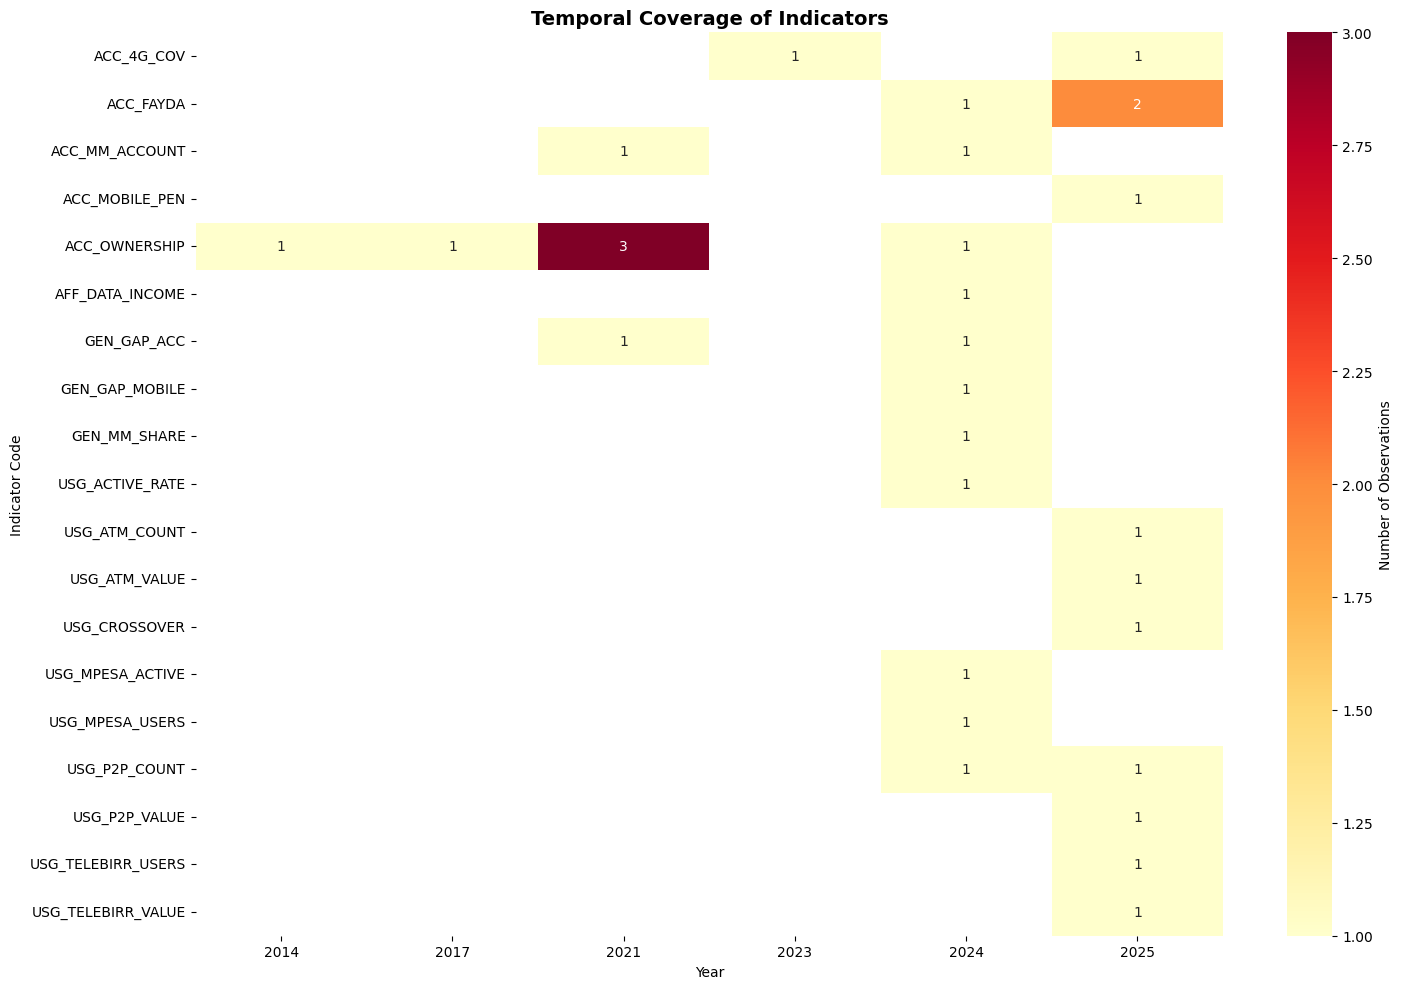

In [ ]:
print("=" * 80)
print("TEMPORAL COVERAGE VISUALIZATION")
print("=" * 80)

obs_pivot = observations.pivot_table(
    index='indicator_code',
    columns=pd.to_datetime(observations['observation_date']).dt.year,
    values='value_numeric',
    aggfunc='count'
)

plt.figure(figsize=(15, 10))
sns.heatmap(obs_pivot, annot=True, cmap='YlOrRd', fmt='g', cbar_kws={'label': 'Number of Observations'})
plt.title('Temporal Coverage of Indicators', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Indicator Code')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 80)
print("REFERENCE CODES")
print("=" * 80)

for col in reference_df.columns:
    print(f"\n{col}:")
    print(reference_df[col].dropna().unique().tolist())

REFERENCE CODES

field:
['record_type', 'category', 'pillar', 'indicator_direction', 'value_type', 'source_type', 'confidence', 'gender', 'location', 'relationship_type', 'impact_direction', 'impact_magnitude', 'evidence_basis']

code:
['observation', 'event', 'impact_link', 'target', 'baseline', 'forecast', 'product_launch', 'market_entry', 'market_exit', 'policy', 'regulation', 'infrastructure', 'partnership', 'milestone', 'economic', 'pricing', 'ACCESS', 'USAGE', 'QUALITY', 'AFFORDABILITY', 'TRUST', 'DEPTH', 'GENDER', 'higher_better', 'lower_better', 'neutral', 'percentage', 'count', 'currency_etb', 'currency_usd', 'ratio', 'rate', 'index', 'gap_pp', 'boolean', 'categorical', 'text', 'survey', 'operator', 'regulator', 'news', 'research', 'calculated', 'field', 'high', 'medium', 'low', 'estimated', 'all', 'male', 'female', 'national', 'urban', 'rural', 'direct', 'indirect', 'enabling', 'constraining', 'increase', 'decrease', 'stabilize', 'mixed', 'negligible', 'empirical', 'literatur

In [ ]:
print("=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

available_columns = df.columns.tolist()
print("Available columns for duplicate check:", available_columns)

duplicate_subset = []
for col in ['record_type', 'indicator_code', 'observation_date', 'name']:
    if col in df.columns:
        duplicate_subset.append(col)

if duplicate_subset:
    duplicates = df.duplicated(subset=duplicate_subset).sum()
    print(f"Potential duplicates: {duplicates}")
else:
    print("Cannot check duplicates - required columns not found")

date_issues = 0
for date_col in ['observation_date', 'collection_date']:
    if date_col in df.columns:
        try:
            pd.to_datetime(df[date_col])
        except:
            date_issues += 1
    else:
        print(f"Column '{date_col}' not found")
print(f"Date format issues: {date_issues}")

if 'description' in df.columns:
    empty_desc = df['description'].isnull().sum()
    print(f"Missing descriptions: {empty_desc} ({empty_desc/len(df)*100:.1f}%)")
else:
    print("Column 'description' not found")

if 'source_name' in df.columns:
    empty_sources = df['source_name'].isnull().sum()
    print(f"Missing source names: {empty_sources} ({empty_sources/len(df)*100:.1f}%)")
else:
    print("Column 'source_name' not found")

quality_summary = {
    'Total Records': len(df),
    'Record Types': df['record_type'].unique().tolist(),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Rows': duplicates if duplicate_subset else 'N/A',
    'Date Range': f"{df['observation_date'].min()} to {df['observation_date'].max()}" if 'observation_date' in df.columns else 'N/A'
}

print("\n" + "=" * 40)
print("DATA QUALITY SUMMARY")
print("=" * 40)
for key, value in quality_summary.items():
    print(f"{key}: {value}")

DATA QUALITY ASSESSMENT
Available columns for duplicate check: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']
Potential duplicates: 2
Date format issues: 1
Column 'description' not found
Missing source names: 0 (0.0%)

DATA QUALITY SUMMARY
Total Records: 43
Record Types: ['observation', 'target', 'event']
Missing Values: 614
Duplicate Rows: 2
Date Range: 2014-12-31 00:00:00 to 2030-12-31 00:00:00


In [ ]:
print("=" * 80)
print("DATA GAPS IDENTIFICATION")
print("=" * 80)

if 'observation_date' in observations.columns:
    year_range = pd.to_datetime(observations['observation_date']).dt.year
    available_years = sorted(year_range.unique())
    print(f"Years with data: {available_years}")

    indicators_with_gaps = {}
    for indicator in observations['indicator_code'].unique():
        indicator_data = observations[observations['indicator_code'] == indicator]
        years_present = pd.to_datetime(indicator_data['observation_date']).dt.year.unique()
        missing_years = [y for y in range(2011, 2025) if y not in years_present and y >= 2011]
        if missing_years:
            indicators_with_gaps[indicator] = missing_years

    print(f"\nIndicators with gaps: {len(indicators_with_gaps)}")
    print("\nSample gaps:")
    for i, (indicator, years) in enumerate(list(indicators_with_gaps.items())[:5]):
        print(f"  {indicator}: missing {years}")
else:
    print("Column 'observation_date' not found in observations")

DATA GAPS IDENTIFICATION
Years with data: [np.int32(2014), np.int32(2017), np.int32(2021), np.int32(2023), np.int32(2024), np.int32(2025)]

Indicators with gaps: 19

Sample gaps:
  ACC_OWNERSHIP: missing [2011, 2012, 2013, 2015, 2016, 2018, 2019, 2020, 2022, 2023]
  ACC_MM_ACCOUNT: missing [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2022, 2023]
  ACC_4G_COV: missing [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2024]
  ACC_MOBILE_PEN: missing [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  ACC_FAYDA: missing [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


SOURCE ANALYSIS
Data sources:
source_name
Global Findex 2021           5
EthSwitch Annual Report      5
Global Findex 2024           3
NBE                          3
Ethio Telecom LEAD Report    2
Calculated                   2
Ethio Telecom Report         2
EthSwitch                    2
News                         2
Safaricom Results            2
World Bank                   1
ID4Africa Conference         1
DataReportal Digital 2026    1
Global Findex 2017           1
Global Findex 2014           1
Fayda Official               1
A4AI/ITU                     1
NFIS-II Strategy             1
GSMA Gender Gap Report       1
NBE/Shega                    1
Fayda/NIDP                   1
Ethio Telecom                1
Safaricom                    1
NIDP                         1
NBE/EthSwitch                1
Name: count, dtype: int64

Sources by record type:
record_type                event  observation  target
source_name                                          
A4AI/ITU                

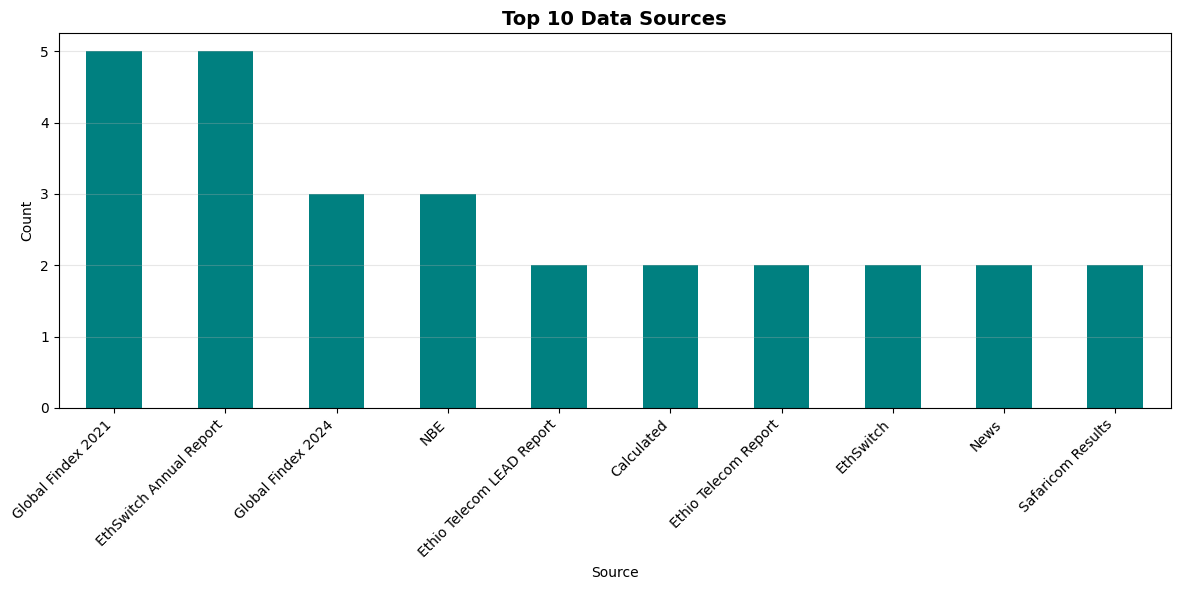

In [ ]:
print("=" * 80)
print("SOURCE ANALYSIS")
print("=" * 80)

if 'source_name' in df.columns:
    source_counts = df['source_name'].value_counts()
    print("Data sources:")
    print(source_counts)

    source_by_type = pd.crosstab(df['source_name'], df['record_type'])
    print("\nSources by record type:")
    print(source_by_type)

    plt.figure(figsize=(12, 6))
    source_counts.head(10).plot(kind='bar', color='teal')
    plt.title('Top 10 Data Sources', fontsize=14, fontweight='bold')
    plt.xlabel('Source')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'source_name' not found")

In [ ]:
print("=" * 80)
print("ENRICHMENT PLAN")
print("=" * 80)

print("Based on the exploration, consider adding:")
print("\n1. Additional Observations:")
print("   - Gender-disaggregated account ownership")
print("   - Urban/rural breakdowns")
print("   - Regional data from NBE reports")
print("   - Additional years of infrastructure data")
print("   - Mobile money transaction volumes")
print("   - Agent network density")

print("\n2. Additional Events:")
print("   - Policy changes (e.g., NBE directives)")
print("   - Infrastructure investments")
print("   - Partnership announcements")
print("   - Regulatory changes")

print("\n3. Additional Impact Links:")
print("   - Event-to-indicator relationships from literature")
print("   - Comparable country evidence")
print("   - Expert assessments")

print("\n4. Data Quality Improvements:")
print("   - Fill missing descriptions")
print("   - Standardize source names")
print("   - Validate date formats")

ENRICHMENT PLAN
Based on the exploration, consider adding:

1. Additional Observations:
   - Gender-disaggregated account ownership
   - Urban/rural breakdowns
   - Regional data from NBE reports
   - Additional years of infrastructure data
   - Mobile money transaction volumes
   - Agent network density

2. Additional Events:
   - Policy changes (e.g., NBE directives)
   - Infrastructure investments
   - Partnership announcements
   - Regulatory changes

3. Additional Impact Links:
   - Event-to-indicator relationships from literature
   - Comparable country evidence
   - Expert assessments

4. Data Quality Improvements:
   - Fill missing descriptions
   - Standardize source names
   - Validate date formats


In [ ]:
with open('reports/data_exploration_summary.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("DATA EXPLORATION SUMMARY\n")
    f.write("=" * 80 + "\n\n")

    f.write(f"Dataset shape: {df.shape}\n")
    f.write(f"Record types: {df['record_type'].unique().tolist()}\n")
    if 'pillar' in df.columns:
        f.write(f"Pillars: {df['pillar'].unique().tolist()}\n")
    f.write(f"Indicators: {df['indicator_code'].nunique()}\n")
    if 'observation_date' in df.columns:
        f.write(f"Date range: {df['observation_date'].min()} to {df['observation_date'].max()}\n\n")

    f.write("Record type counts:\n")
    f.write(record_type_counts.to_string())
    f.write("\n\nConfidence distribution:\n")
    f.write(confidence_dist.to_string())
    f.write("\n\nIndicator coverage:\n")
    if 'indicator_summary' in locals():
        f.write(indicator_summary.to_string())
    f.write("\n\nData quality metrics:\n")
    for key, value in quality_summary.items():
        f.write(f"{key}: {value}\n")
    f.write("\n\nIdentified gaps:\n")
    if 'indicators_with_gaps' in locals():
        for indicator, years in list(indicators_with_gaps.items())[:10]:
            f.write(f"{indicator}: missing {years}\n")

print("Exploration summary saved to reports/data_exploration_summary.txt")

from google.colab import files
files.download('reports/data_exploration_summary.txt')

Exploration summary saved to reports/data_exploration_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("=" * 80)
print("DATA ENRICHMENT LOG TEMPLATE")
print("=" * 80)
print("""
data_enrichment_log.md

Data Enrichment Log

New Observations Added

| Date | Indicator | Indicator Code | Value | Source | Source URL | Confidence | Collected By | Collection Date | Notes |
|------|-----------|----------------|-------|--------|------------|------------|--------------|----------------|-------|
| 2026-07-15 | Account Ownership (Female) | ACC_OWN_FEMALE | 45.2% | Global Findex | https://... | high | Your Name | 2026-07-15 | Gender-disaggregated data from Findex 2024 |

New Events Added

| Date | Event Name | Category | Description | Source | Source URL | Confidence | Collected By | Collection Date | Notes |
|------|------------|----------|-------------|--------|------------|------------|--------------|----------------|-------|
| 2025-06-01 | New Digital ID Integration | policy | Fayda ID integration with mobile money | NBE | https://... | medium | Your Name | 2026-07-15 | Announced in Q2 2025 |

New Impact Links Added

| Event | Pillar | Related Indicator | Impact Direction | Impact Magnitude | Lag (months) | Evidence Basis | Added By | Notes |
|-------|--------|-------------------|------------------|------------------|--------------|----------------|----------|-------|
| Telebirr Launch | access | ACC_OWNERSHIP | positive | 5.0 | 12 | Kenya M-Pesa case study | Your Name | Based on Suri & Jack (2016) |

Data Quality Notes

Limitations
- Sparse data for 2025
- Limited disaggregated data

Gaps
- No regional breakdowns
- Missing gender gap data

Assumptions
- Linear interpolation for missing years

Sources Consulted
1. Global Findex Database 2024
2. GSMA State of the Industry Report 2025
3. NBE Annual Report 2025
""")

print("Use this template for data_enrichment_log.md")

DATA ENRICHMENT LOG TEMPLATE

data_enrichment_log.md

Data Enrichment Log

New Observations Added

| Date | Indicator | Indicator Code | Value | Source | Source URL | Confidence | Collected By | Collection Date | Notes |
|------|-----------|----------------|-------|--------|------------|------------|--------------|----------------|-------|
| 2026-07-15 | Account Ownership (Female) | ACC_OWN_FEMALE | 45.2% | Global Findex | https://... | high | Your Name | 2026-07-15 | Gender-disaggregated data from Findex 2024 |

New Events Added

| Date | Event Name | Category | Description | Source | Source URL | Confidence | Collected By | Collection Date | Notes |
|------|------------|----------|-------------|--------|------------|------------|--------------|----------------|-------|
| 2025-06-01 | New Digital ID Integration | policy | Fayda ID integration with mobile money | NBE | https://... | medium | Your Name | 2026-07-15 | Announced in Q2 2025 |

New Impact Links Added

| Event | Pillar | Rel

In [ ]:
print("=" * 80)
print("EXPLORATION COMPLETE - NEXT STEPS")
print("=" * 80)
print("""
1. Review the exploration results
2. Identify specific data to add:
   - Check the Additional Data Points Guide
   - Research sources for missing indicators
   - Find events not yet captured
3. Create data_enrichment_log.md
4. Add new observations, events, and impact links
5. Validate the enriched dataset
6. Save to processed/ directory
""")

print(f"\nCurrent working directory: {os.getcwd()}")
print(f"\nFiles available:")
for file in os.listdir():
    if file.endswith('.csv') or file.endswith('.xlsx'):
        print(f"  - {file}")

EXPLORATION COMPLETE - NEXT STEPS

1. Review the exploration results
2. Identify specific data to add:
   - Check the Additional Data Points Guide
   - Research sources for missing indicators
   - Find events not yet captured
3. Create data_enrichment_log.md
4. Add new observations, events, and impact links
5. Validate the enriched dataset
6. Save to processed/ directory


Current working directory: /content

Files available:
  - ethiopia_fi_unified_data.xlsx
  - reference_codes.xlsx
  - ethiopia_fi_unified_data (1).xlsx


In [ ]:
os.makedirs('reports', exist_ok=True)
indicator_summary.to_csv('reports/indicator_coverage.csv')
print("indicator_coverage.csv created successfully")

import os
if os.path.exists('reports/indicator_coverage.csv'):
    print("File verified in reports/indicator_coverage.csv")
else:
    print("File not found")

indicator_coverage.csv created successfully
File verified in reports/indicator_coverage.csv


In [ ]:
from google.colab import files
files.download('reports/indicator_coverage.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>